In [179]:
import numpy as np
from pathlib import Path
from typing import Dict, Optional, Tuple
from dataclasses import dataclass
from PIL import Image
import matplotlib.pyplot as plt

pathA = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/weights/bokeh_fl45.0_as6_samples500000_od500_lidx0of8.png")
pathB = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/weights/bokeh_fl45.0_as6_samples500000_od500_lidx6of8.png")

desired_resolution: Optional[Tuple[int, int]] = (50, 50)  # (height, width); set None to keep native size

def load_gray(path: Path, resolution: Optional[Tuple[int, int]] = None, resample: int = Image.BICUBIC) -> np.ndarray:
    with Image.open(path) as img:
        if resolution is not None:
            target_height, target_width = resolution
            target_height = int(target_height)
            target_width = int(target_width)
            if target_height <= 0 or target_width <= 0:
                raise ValueError("Resolution values must be positive integers")
            if img.size != (target_width, target_height):
                img = img.resize((target_width, target_height), resample=resample)
        data = np.asarray(img, dtype=np.float64)
    if data.ndim == 3:
        data = data[..., 0]
    
    data /= max(np.sum(data), 1e-12)
    return np.clip(data, 0.0, None)

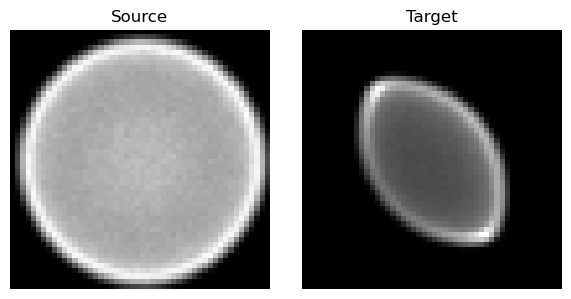

((50, 50), (50, 50))

In [180]:
source_image = load_gray(pathA, desired_resolution)
target_image = load_gray(pathB, desired_resolution)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(source_image, cmap="gray")
axes[0].set_title("Source")
axes[0].axis("off")
axes[1].imshow(target_image, cmap="gray")
axes[1].set_title("Target")
axes[1].axis("off")
plt.tight_layout()
plt.show()

source_image.shape, target_image.shape

In [181]:
@dataclass
class BilinearContext:
    y0: np.ndarray
    x0: np.ndarray
    y1: np.ndarray
    x1: np.ndarray
    fy: np.ndarray
    fx: np.ndarray
    Ia: np.ndarray
    Ib: np.ndarray
    Ic: np.ndarray
    Id: np.ndarray
    mask: np.ndarray


def _prepare_bilinear(image: np.ndarray, sample_y: np.ndarray, sample_x: np.ndarray) -> BilinearContext:
    h, w = image.shape
    if h < 1 or w < 1:
        raise ValueError("Image must have positive spatial dimensions")
    valid_y = (sample_y >= 0.0) & (sample_y <= h - 1)
    valid_x = (sample_x >= 0.0) & (sample_x <= w - 1)
    mask = (valid_y & valid_x).astype(np.float64)
    sample_y = np.clip(sample_y, 0.0, float(h - 1))
    sample_x = np.clip(sample_x, 0.0, float(w - 1))
    y0 = np.floor(sample_y).astype(np.int32)
    x0 = np.floor(sample_x).astype(np.int32)
    y1 = np.clip(y0 + 1, 0, h - 1)
    x1 = np.clip(x0 + 1, 0, w - 1)
    fy = sample_y - y0
    fx = sample_x - x0
    Ia = image[y0, x0]
    Ib = image[y0, x1]
    Ic = image[y1, x0]
    Id = image[y1, x1]
    return BilinearContext(y0, x0, y1, x1, fy, fx, Ia, Ib, Ic, Id, mask)


def apply_distortion(image: np.ndarray, distortion: np.ndarray, coords: Optional[Tuple[np.ndarray, np.ndarray]] = None, return_ctx: bool = False):
    if image.shape != distortion.shape[:2]:
        raise ValueError("Distortion shape must match image spatial dimensions")
    if coords is None:
        coords = np.meshgrid(
            np.arange(image.shape[0], dtype=np.float64),
            np.arange(image.shape[1], dtype=np.float64),
            indexing="ij",
        )
    grid_y, grid_x = coords
    sample_y = grid_y + distortion[..., 0]
    sample_x = grid_x + distortion[..., 1]
    ctx = _prepare_bilinear(image, sample_y, sample_x)
    blended = (
        (1.0 - ctx.fy) * (1.0 - ctx.fx) * ctx.Ia
        + (1.0 - ctx.fy) * ctx.fx * ctx.Ib
        + ctx.fy * (1.0 - ctx.fx) * ctx.Ic
        + ctx.fy * ctx.fx * ctx.Id
    )
    warped = ctx.mask * blended
    if return_ctx:
        return warped, ctx
    return warped


def _loss_and_grad(distortion: np.ndarray, source: np.ndarray, target: np.ndarray, coords: Tuple[np.ndarray, np.ndarray]):
    warped, ctx = apply_distortion(source, distortion, coords=coords, return_ctx=True)
    residual = warped - target
    loss = 0.5 * np.mean(residual**2)
    scale = residual / residual.size
    base_grad_y = (1.0 - ctx.fx) * (ctx.Ic - ctx.Ia) + ctx.fx * (ctx.Id - ctx.Ib)
    base_grad_x = (1.0 - ctx.fy) * (ctx.Ib - ctx.Ia) + ctx.fy * (ctx.Id - ctx.Ic)
    grad_y = ctx.mask * base_grad_y
    grad_x = ctx.mask * base_grad_x
    grad = np.stack([scale * grad_y, scale * grad_x], axis=-1)
    return float(loss), grad


def _laplacian(field: np.ndarray) -> np.ndarray:
    lap = -4.0 * field  # 4-neighbor Laplacian encourages smooth distortion field
    lap[:-1] += field[1:]
    lap[1:] += field[:-1]
    lap[:, :-1] += field[:, 1:]
    lap[:, 1:] += field[:, :-1]
    return lap


def gradient_descent(
    source: np.ndarray,
    target: np.ndarray,
    iterations: int = 250,
    step_size: float = 0.4,
    momentum: float = 0.6,
    smooth_weight: float = 0.02,
    callback: Optional = None,
 ) -> Tuple[np.ndarray, np.ndarray]:
    if source.shape != target.shape:
        raise ValueError("Source and target must share the same spatial shape")
    h, w = source.shape
    coords = np.meshgrid(
        np.arange(h, dtype=np.float64),
        np.arange(w, dtype=np.float64),
        indexing="ij",
    )
    min_dy = -coords[0]
    max_dy = (h - 1) - coords[0]
    min_dx = -coords[1]
    max_dx = (w - 1) - coords[1]
    center_y = 0.5 * (h - 1)
    center_x = 0.5 * (w - 1)
    toward_center = np.stack(
        [center_y - coords[0], center_x - coords[1]],
        axis=-1,
    )
    init_scale = 0.01
    distortion = init_scale * toward_center
    distortion[..., 0] = np.clip(distortion[..., 0], min_dy, max_dy)
    distortion[..., 1] = np.clip(distortion[..., 1], min_dx, max_dx)
    velocity = np.zeros_like(distortion)
    history = []

    for it in range(iterations):
        loss, grad = _loss_and_grad(distortion, source, target, coords)
        if smooth_weight > 0.0:
            grad = grad + smooth_weight * _laplacian(distortion)
        velocity = momentum * velocity + grad
        distortion = distortion - step_size * velocity
        distortion[..., 0] = np.clip(distortion[..., 0], min_dy, max_dy)
        distortion[..., 1] = np.clip(distortion[..., 1], min_dx, max_dx)
        history.append(loss)
        if callback is not None:
            callback(it, loss, distortion)
        if not np.isfinite(loss):
            raise FloatingPointError(f"Encountered invalid loss at iteration {it}")
    return distortion, np.asarray(history)

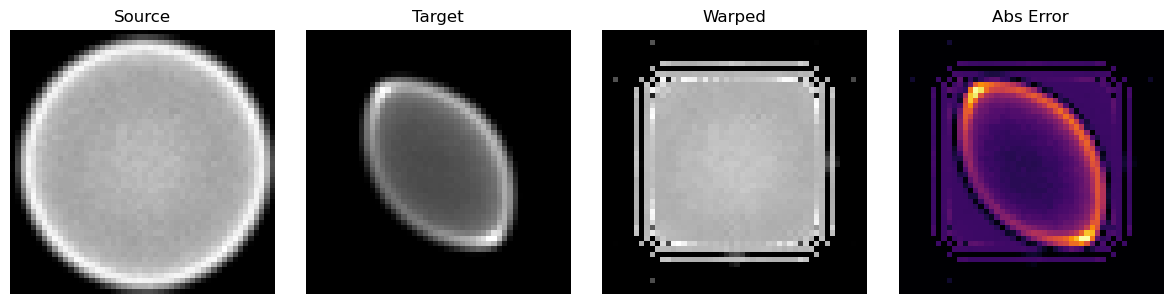

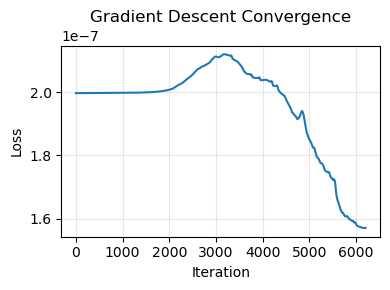

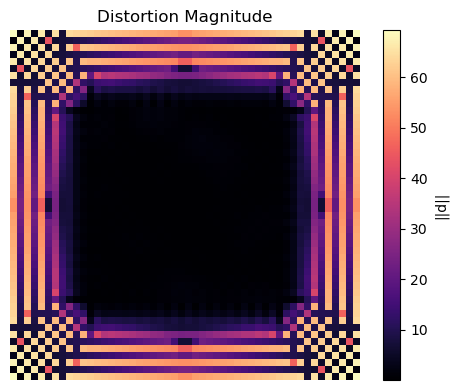

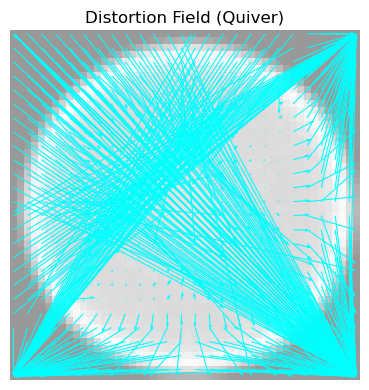

np.float64(69.29646455628166)

In [182]:
distortion_field, loss_history = gradient_descent(
    source_image,
    target_image,
    iterations=6200,
    step_size=0.05,
    momentum=0.001,
    smooth_weight=0.01,
 )

warped_image = apply_distortion(source_image, distortion_field)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(source_image, cmap="gray")
axes[0].set_title("Source")
axes[0].axis("off")
axes[1].imshow(target_image, cmap="gray")
axes[1].set_title("Target")
axes[1].axis("off")
axes[2].imshow(warped_image, cmap="gray")
axes[2].set_title("Warped")
axes[2].axis("off")
axes[3].imshow(np.abs(warped_image - target_image), cmap="inferno")
axes[3].set_title("Abs Error")
axes[3].axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Gradient Descent Convergence")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

dist_magnitude = np.linalg.norm(distortion_field, axis=-1)

plt.figure(figsize=(5, 4))
plt.imshow(dist_magnitude, cmap="magma")
plt.colorbar(label="||d||")
plt.title("Distortion Magnitude")
plt.axis("off")
plt.tight_layout()
plt.show()

step = max(min(source_image.shape[0], source_image.shape[1]) // 20, 1)
grid_y = np.arange(0, source_image.shape[0], step)
grid_x = np.arange(0, source_image.shape[1], step)
sample_y, sample_x = np.meshgrid(grid_y, grid_x, indexing="ij")
samples = distortion_field[::step, ::step]
plt.figure(figsize=(5, 4))
plt.imshow(source_image, cmap="gray", alpha=0.4)
plt.quiver(
    sample_x,
    sample_y,
    samples[..., 1],
    samples[..., 0],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    color="cyan",
    width=0.003,
)
plt.title("Distortion Field (Quiver)")
plt.axis("off")
plt.tight_layout()
plt.show()

dist_magnitude.max()